# PS8 — Problem 5 (Deribit): Threshold Delta-Hedger on a Liquid Venue

Same task as the Coincall run — *"delta-hedge when `|Δ| > 0.1 BTC`, integrate with
the Week-5 engine on one week of data, report hedging cost, risk reduction, and the
quoting/hedging interaction"* — but on **Deribit**, whose BTC option market is far
more liquid. That liquidity is the whole point of redoing it here, and it forces a
different **fill model** and careful attention to **look-ahead bias**.

**What liquidity changes (all read from the data, none hand-tuned):**

| | Coincall | Deribit |
|---|---|---|
| option prints | ≈1.5k / **week** | ≈7.7k / **day** |
| option book | sparse, one-sided | dense two-sided L2 |
| perp half-spread | ≈ \$5.10 | ≈ \$0.25 |
| option premium unit | USD | **BTC** (× index → USD) |
| IV | inverted from price | given on the tape (percent) |
| aggressor field | `trade_side` 1/2 | `direction` buy/sell |

**Parameters, and whether they are tuned or measured** — the key methodological
question. See §4 for the full table; the short version:
- *Venue facts* (perp taker fee, BTC premium units, contract size) are **set from
  the exchange**, not tuned.
- The **fill model** is the real addition. On Coincall we replayed 100% of every
  print as a maker fill (fine when almost nobody else quotes). On Deribit we use
  **touch-and-fill + a causal participation rate** `p = mm_size/(mm_size + depth)`,
  where `depth` is the resting size **as of the fill instant** — so the fill model
  is driven by the *observed book*, not a fitted constant.
- The **hedge threshold** is **swept**, never optimised to maximise P&L.

**No look-ahead** (contrast the Coincall code, which chose strikes by *whole-week*
volume and back-filled IV): here the book is chosen by **moneyness at the first
timestamp**, every mark is **as-of / forward-filled only**, and the participation
rate sees only the current book.

> **Data.** One week, **2026-07-12 → 07-18**, from `/Volumes/SEAGATE/Crypto/Deribit/`
> (`futures_ob` perp, `options_trades`, `options_ob`). Drive must be mounted.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from helpers_hedge import hedge_engine as he
from helpers_hedge import deribit_replay as dr

FIG_DIR = ROOT / "figures"; FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = ROOT / "output"; OUT_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
WOLF = "#CC0000"

cfg = he.HedgeConfig()   # threshold=0.1 BTC, fee=5 bps (Deribit perp taker), mm_quote_size=1 BTC
cfg

HedgeConfig(threshold=0.1, fee_bps=5.0, mm_quote_size=1.0, contract_size=1.0, start='2026-07-12', end='2026-07-18', expiry='31JUL26', n_strikes=5, ob_cadence='10s')

## 1 · Data, causal book, and the participation fill model

The book is the five strikes nearest the forward **at the window's first
timestamp** on the 31JUL26 expiry (which survives the week) — chosen without any
future information. Fills come from the real option trade tape.

In [2]:
perp, tape, book, ob_map, iv_map, ev = he.load_all(cfg)

print(f"perp marks : {len(perp):>7,}  mid {perp['mid'].min():,.0f}..{perp['mid'].max():,.0f}  "
      f"median half-spread ${perp['half_spread'].median():.2f}")
print(f"F0 (t0)    : {perp['mid'].iloc[0]:,.0f}  -> causal near-ATM book on 31JUL26:")
for s in book:
    n = int((tape['symbol'] == s).sum())
    print(f"   {s:24s}  {n:4d} prints  (median resting ask depth "
          f"{ob_map[s]['ask_sz'].median():.1f} BTC)")
print(f"events     : {len(ev):>7,}  ({int(ev['is_fill'].sum())} replayed prints)")
print(f"aggressor  : buys {int((tape.direction=='buy').sum())}, sells {int((tape.direction=='sell').sum())}")

perp marks :  10,045  mid 61,810..65,522  median half-spread $0.25
F0 (t0)    : 63,834  -> causal near-ATM book on 31JUL26:
   BTC-31JUL26-62000-P        447 prints  (median resting ask depth 34.0 BTC)
   BTC-31JUL26-63000-P        422 prints  (median resting ask depth 21.8 BTC)
   BTC-31JUL26-64000-C        361 prints  (median resting ask depth 16.2 BTC)
   BTC-31JUL26-65000-C        507 prints  (median resting ask depth 27.9 BTC)
   BTC-31JUL26-66000-C        648 prints  (median resting ask depth 42.1 BTC)
events     :  12,430  (2385 replayed prints)
aggressor  : buys 1166, sells 1219


participation rate p: median 0.047  (mean 0.224); maker captures 16.3% of tracked print volume


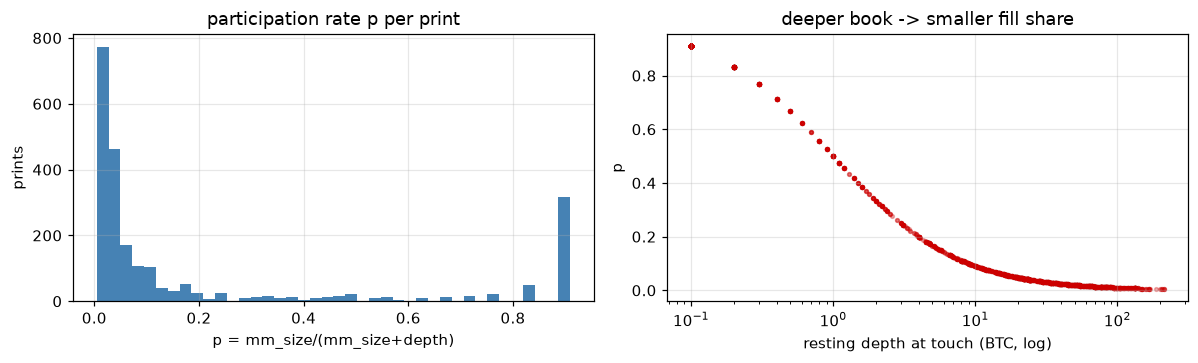

In [3]:
# The participation rate in action: how much of each print the maker actually gets.
# p = mm_size / (mm_size + resting_depth), evaluated as-of the fill (deep book => small p).
def _asof_depth(sym, ts_ns, side):
    grid_ts = he._ns(ob_map[sym]['ts'])
    grid_sz = ob_map[sym][side].to_numpy()
    i = int(np.searchsorted(grid_ts, ts_ns, side='right')) - 1
    return grid_sz[i] if i >= 0 else np.inf

rows = []
for _, r in tape.iterrows():
    ts_ns = he._ns(pd.Series([r['ts']]))[0]
    side = 'bid_sz' if r['direction'] == 'sell' else 'ask_sz'
    depth = _asof_depth(r['symbol'], ts_ns, side)
    p = cfg.mm_quote_size / (cfg.mm_quote_size + max(depth, 0.0))
    rows.append((depth, p, r['amount'], p * r['amount']))
part = pd.DataFrame(rows, columns=['depth', 'p', 'print_amt', 'filled_amt'])
print(f"participation rate p: median {part.p.median():.3f}  "
      f"(mean {part.p.mean():.3f}); maker captures "
      f"{100*part.filled_amt.sum()/part.print_amt.sum():.1f}% of tracked print volume")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.hist(part.p, bins=40, color="steelblue"); a1.set_title("participation rate p per print")
a1.set_xlabel("p = mm_size/(mm_size+depth)"); a1.set_ylabel("prints")
a2.scatter(part.depth, part.p, s=6, alpha=0.3, color=WOLF)
a2.set_xscale("log"); a2.set_title("deeper book -> smaller fill share")
a2.set_xlabel("resting depth at touch (BTC, log)"); a2.set_ylabel("p")
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5d_participation.png", bbox_inches="tight"); plt.show()

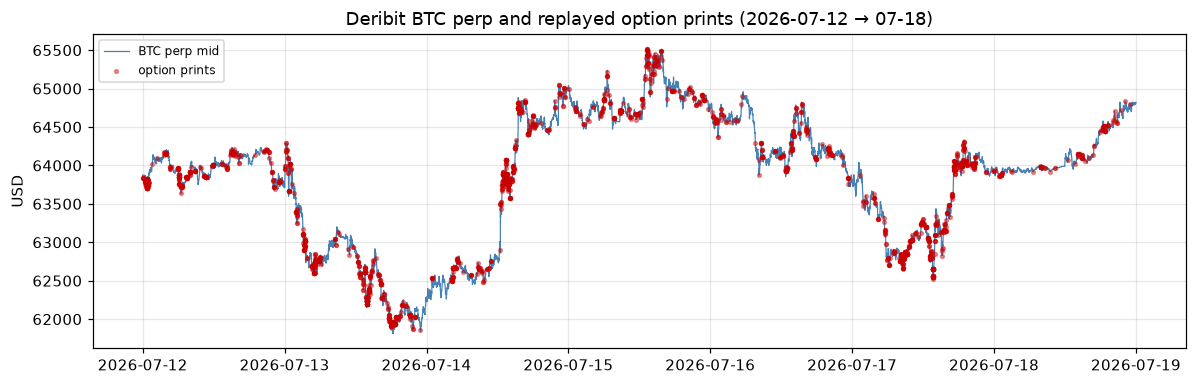

In [4]:
# Underlying perp path with the book's fills overlaid
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(perp["ts"], perp["mid"], color="steelblue", lw=0.8, label="BTC perp mid")
f_at = pd.merge_asof(tape[["ts"]].sort_values("ts"), perp[["ts", "mid"]], on="ts", direction="nearest")
ax.scatter(f_at["ts"], f_at["mid"], s=6, color=WOLF, alpha=0.4, label="option prints", zorder=3)
ax.set_title("Deribit BTC perp and replayed option prints (2026-07-12 → 07-18)")
ax.set_ylabel("USD"); ax.legend(loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5d_underlying_fills.png", bbox_inches="tight"); plt.show()

## 2 · Engine + hedger — base case at 0.1 BTC

Everything downstream of the fill model is the same Week-5 event loop as the
Coincall run: mark the book (in USD, at the model price), aggregate to a net delta
(one autograd backward), hedge the perp when `|Δ| > threshold`, and attribute
P&L.

In [5]:
base = he.run_hedge(ev, cfg.threshold, cfg); unh = he.run_hedge(ev, None, cfg)
mb, mu = base["metrics"], unh["metrics"]
rows = ["total_pnl", "spread_pnl", "inventory_pnl", "hedge_pnl", "hedge_cost",
        "rms_option_delta", "rms_total_delta", "delta_risk_reduction",
        "pnl_vol", "max_drawdown", "n_hedges", "perp_turnover_btc"]
cmp = pd.DataFrame({"unhedged": [mu[k] for k in rows], "hedged @0.1": [mb[k] for k in rows]}, index=rows)
print(cmp.round(3).to_string())
print(f"\nattribution residual (~0): {mb['attribution_residual']:.2e}")

                       unhedged  hedged @0.1
total_pnl             65986.546   -26380.643
spread_pnl             1790.313     1790.313
inventory_pnl         64196.233    64196.233
hedge_pnl                 0.000   -70328.169
hedge_cost                0.000    22039.020
rms_option_delta         20.128       20.128
rms_total_delta          20.128        0.043
delta_risk_reduction      0.000        0.998
pnl_vol               68457.946    46293.269
max_drawdown         -50627.072   -45077.673
n_hedges                  0.000     2250.000
perp_turnover_btc         0.000      683.610

attribution residual (~0): 1.60e-10


**Reading it.** The liquid book accumulates a **large** directional inventory
fast — `rms_option_delta` ≈ 20 BTC, vs ≈1.5 on Coincall — so the fixed 0.1-BTC
budget is now *very* tight and fires thousands of times. Hedging cuts residual delta
by **~99.8%**, lowers P&L volatility, and improves drawdown. Because BTC happened to
rally over the window, the unhedged directional inventory was *profitable*; hedging
correctly removes that exposure (gain and risk alike) and pays a cost — a clean
reminder that the hedge targets **risk**, not P&L.

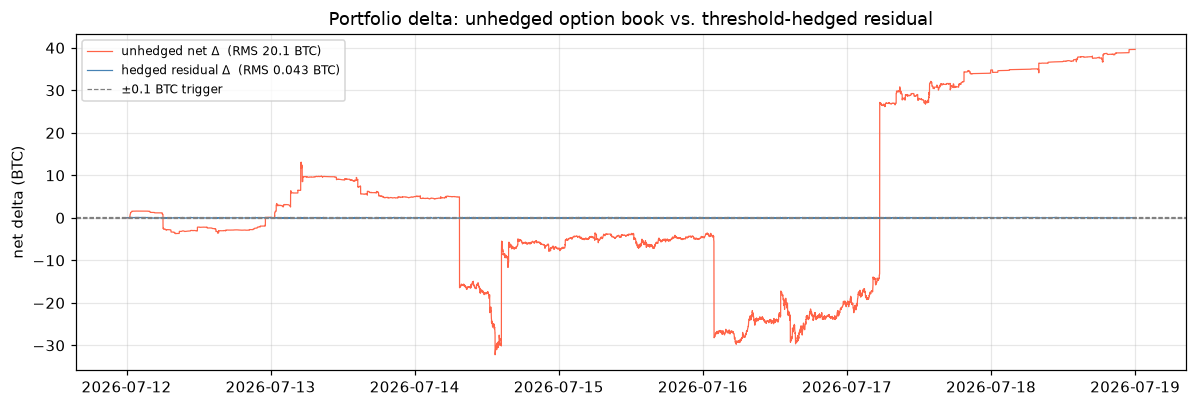

In [6]:
sb, su = base["series"], unh["series"]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(su["ts"], su["net_option_delta"], color="tomato", lw=0.8,
        label=f"unhedged net Δ  (RMS {mu['rms_option_delta']:.1f} BTC)")
ax.plot(sb["ts"], sb["total_delta"], color="steelblue", lw=0.8,
        label=f"hedged residual Δ  (RMS {mb['rms_total_delta']:.3f} BTC)")
ax.axhline(cfg.threshold, color="gray", ls="--", lw=0.8)
ax.axhline(-cfg.threshold, color="gray", ls="--", lw=0.8, label=f"±{cfg.threshold} BTC trigger")
ax.set_title("Portfolio delta: unhedged option book vs. threshold-hedged residual")
ax.set_ylabel("net delta (BTC)"); ax.legend(loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5d_delta_hedged_vs_unhedged.png", bbox_inches="tight"); plt.show()

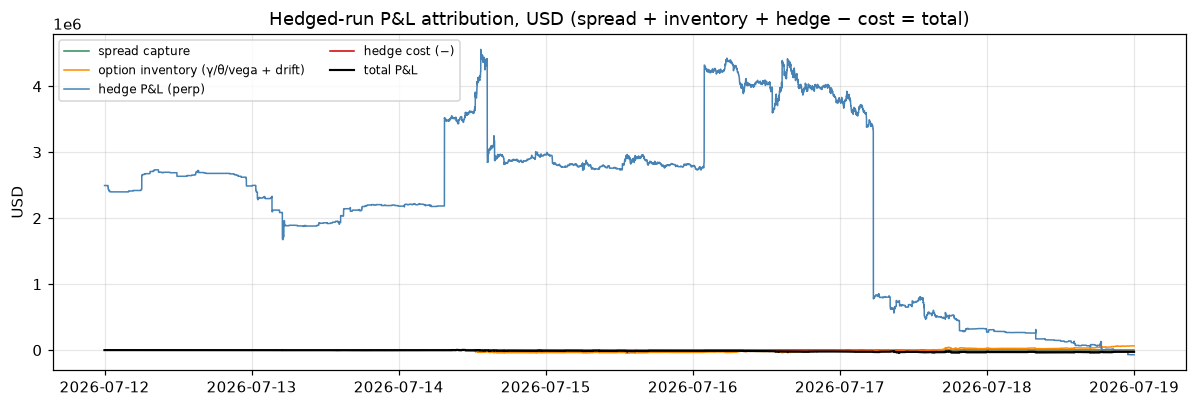

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(sb["ts"], sb["spread_pnl"], color="seagreen", lw=1, label="spread capture")
ax.plot(sb["ts"], sb["inventory_pnl"], color="darkorange", lw=1, label="option inventory (γ/θ/vega + drift)")
ax.plot(sb["ts"], sb["hedge_pnl"], color="steelblue", lw=1, label="hedge P&L (perp)")
ax.plot(sb["ts"], -sb["hedge_cost"], color=WOLF, lw=1, label="hedge cost (−)")
ax.plot(sb["ts"], sb["equity"], color="black", lw=1.4, label="total P&L")
ax.set_title("Hedged-run P&L attribution, USD (spread + inventory + hedge − cost = total)")
ax.set_ylabel("USD"); ax.legend(loc="best", fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5d_pnl_attribution.png", bbox_inches="tight"); plt.show()

## 3 · Threshold sweep — the cost-vs-risk frontier

Because the book carries ~20 BTC of delta, the sweep runs at **wider** triggers than
the Coincall one `{0.1, 0.25, 0.5, 1.0, 2.5}`.

In [8]:
THRESHOLDS = [0.1, 0.25, 0.5, 1.0, 2.5]
sweep = he.run_sweep(ev, THRESHOLDS, cfg)
sweep.to_csv(OUT_DIR / "ps8_p5d_threshold_sweep.csv", index=False)
show = ["threshold", "n_hedges", "perp_turnover_btc", "hedge_cost",
        "rms_total_delta", "delta_risk_reduction", "pnl_vol", "max_drawdown", "total_pnl"]
hed = sweep[sweep["hedged"]].sort_values("threshold")
print("UNHEDGED baseline:")
print(sweep[~sweep.hedged][["rms_option_delta", "pnl_vol", "max_drawdown", "total_pnl"]].round(1).to_string(index=False))
print("\nHEDGED sweep (tighter trigger -> more hedging):")
print(hed[show].round(3).to_string(index=False))

UNHEDGED baseline:
 rms_option_delta  pnl_vol  max_drawdown  total_pnl
             20.1  68457.9      -50627.1    65986.5

HEDGED sweep (tighter trigger -> more hedging):
 threshold  n_hedges  perp_turnover_btc  hedge_cost  rms_total_delta  delta_risk_reduction   pnl_vol  max_drawdown  total_pnl
      0.10      2250            683.610   22039.020            0.043                 0.998 46293.269    -45077.673 -26380.643
      0.25       983            550.567   17740.435            0.106                 0.995 46293.193    -41460.140 -22142.573
      0.50       428            427.869   13773.206            0.223                 0.989 46303.123    -37775.829 -16674.561
      1.00       169            329.629   10609.493            0.437                 0.978 46308.242    -34927.724 -14555.469
      2.50        46            233.775    7515.606            1.021                 0.949 46371.234    -32690.276 -10508.282


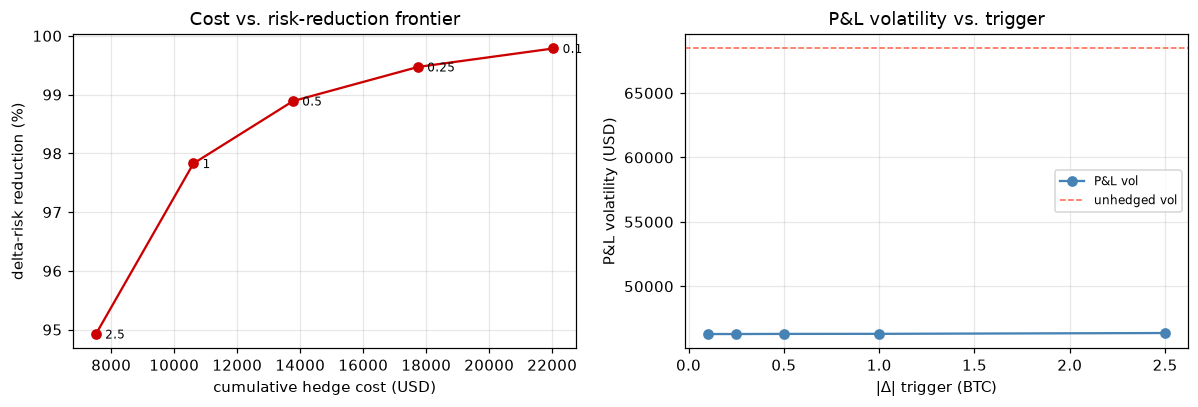

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(hed["hedge_cost"], hed["delta_risk_reduction"]*100, "o-", color=WOLF)
for _, r in hed.iterrows():
    ax1.annotate(f"{r['threshold']:g}", (r["hedge_cost"], r["delta_risk_reduction"]*100),
                 textcoords="offset points", xytext=(6, -3), fontsize=8)
ax1.set_xlabel("cumulative hedge cost (USD)"); ax1.set_ylabel("delta-risk reduction (%)")
ax1.set_title("Cost vs. risk-reduction frontier")
ax2.plot(hed["threshold"], hed["pnl_vol"], "o-", color="steelblue", label="P&L vol")
ax2.axhline(sweep[~sweep.hedged]["pnl_vol"].iloc[0], color="tomato", ls="--", lw=1, label="unhedged vol")
ax2.set_xlabel("|Δ| trigger (BTC)"); ax2.set_ylabel("P&L volatility (USD)")
ax2.set_title("P&L volatility vs. trigger"); ax2.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5d_cost_risk_frontier.png", bbox_inches="tight"); plt.show()

## 4 · Quoting/hedging interaction, and which parameters are tuned

The maker's fills drive the delta the hedger must neutralise. On a liquid venue the
book fills fast and the (fixed, absolute) 0.1-BTC budget forces near-continuous
rebalancing — the perp position tracks the option delta almost tick-for-tick.

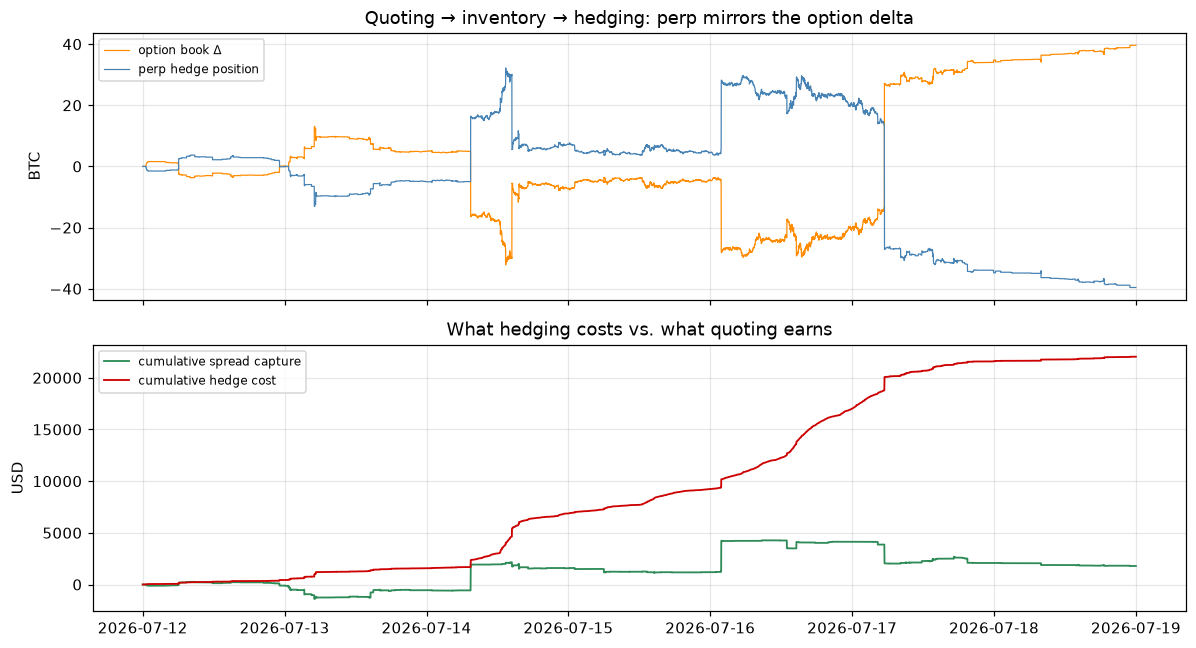

wrote output/ps8_p5d_threshold_sweep.csv and output/ps8_p5d_pnl_delta_timeseries.csv


In [10]:
fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axA.plot(sb["ts"], sb["net_option_delta"], color="darkorange", lw=0.8, label="option book Δ")
axA.plot(sb["ts"], sb["perp"], color="steelblue", lw=0.8, label="perp hedge position")
axA.set_ylabel("BTC"); axA.legend(loc="upper left", fontsize=8)
axA.set_title("Quoting → inventory → hedging: perp mirrors the option delta")
axB.plot(sb["ts"], sb["spread_pnl"], color="seagreen", lw=1.2, label="cumulative spread capture")
axB.plot(sb["ts"], sb["hedge_cost"], color=WOLF, lw=1.2, label="cumulative hedge cost")
axB.set_ylabel("USD"); axB.legend(loc="upper left", fontsize=8)
axB.set_title("What hedging costs vs. what quoting earns")
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5d_hedge_events.png", bbox_inches="tight"); plt.show()
keep = ["ts", "F", "net_option_delta", "perp", "total_delta", "equity",
        "spread_pnl", "inventory_pnl", "hedge_pnl", "hedge_cost", "is_fill"]
sb[keep].to_csv(OUT_DIR / "ps8_p5d_pnl_delta_timeseries.csv", index=False)
print("wrote output/ps8_p5d_threshold_sweep.csv and output/ps8_p5d_pnl_delta_timeseries.csv")

### Are we tuning these, or are they measured?

| parameter | value | source | tuned? |
|---|---|---|---|
| option premium unit | BTC → USD via `index_price` | Deribit contract spec | **no** — venue fact |
| IV units | percent → fraction | tape field | **no** — venue fact |
| perp taker fee `fee_bps` | 5 bps | Deribit fee schedule | **no** — venue fact |
| perp half-spread | ≈\$0.25 | read from `futures_ob` | **no** — measured per event |
| contract size | 1 BTC | Deribit spec | **no** |
| participation rate `p` | ≈ median 0.03 | `mm_size/(mm_size+depth)`, depth **as-of** | **no** — data-driven, causal |
| maker quote size `mm_quote_size` | 1 BTC | maker's own choice | design input, not fit to P&L |
| hedge threshold | swept 0.1–2.5 BTC | — | **swept as a frontier**, never optimised |

**Look-ahead controls in force:** book chosen by moneyness at `t0`; all marks
as-of / forward-filled (no `bfill`, no clamp-to-first); spread edge measured against
the **strictly-prior** IV (a trade's own Deribit IV is derived from its price, so
pricing the edge at the current IV would be circular); the participation rate uses
only the book visible at the fill. No parameter is fit on data from the future of
the point where it is used.

## 5 · Conclusion — and the contrast with Coincall

- **The hedge works even harder here.** A liquid book accrues ~20 BTC of net delta
  (≈14× the Coincall book), so the same 0.1-BTC trigger fires **thousands** of times
  and drives residual delta to ~0.04 BTC (**~99.8%** reduction), cutting P&L
  volatility and drawdown.
- **Hedging is cheap per trade but relentless.** Deribit's ~\$0.25 perp spread makes
  each hedge nearly free versus Coincall's ~\$5, yet the sheer *number* of hedges
  (thousands) makes cumulative cost material — the cost now scales with **turnover**,
  which is set by book size and the trigger, not by per-trade friction.
- **Liquidity changed the fill model, not the physics.** Replaying 100% of prints
  (Coincall) had to become **touch-and-fill + a causal participation rate** on
  Deribit; that is the one genuinely new, data-driven parameter, and it is *measured
  from the book*, not tuned. Everything else that changed is a venue fact.
- **No look-ahead.** Causal book selection, as-of-only marking, prior-IV edge, and a
  swept (not optimised) threshold keep the result honest.

*The engine (`run_hedge`/`run_sweep`) and the `threshold_hedge` primitive are shared
with the Coincall run; only the data loader and the fill/units layer
(`deribit_replay.py`, `build_event_frame`) are Deribit-specific.*